# Divar Real Estate Analysis — Hypothesis Testing

**Question:** Is the mean residential area in megacities lower than in small cities?

**Author:** Mahdi Tarrah

**Data:** `data/Divar.csv` · `data/iran_city_classification.csv`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

```
H0:  mean(megacity) >= mean(small city)
H1:  mean(megacity) <  mean(small city)
```

<p dir="rtl" align="right"><font color="#90EE90" face="vazir">
ادعای سوال اینه که میانگین مساحت خونه‌ها تو کلان‌شهرها کمتر از شهرهای کوچیکه و چون فرض صفر همیشه باید علامت تساوی داشته باشه فرض صفر می‌شه اینکه میانگین مساحت تو کلان‌شهر بزرگتر یا مساوی شهر کوچیکه و فرض مقابل اینکه کمتره پس آزمون یک‌طرفه چپه و چون کلان‌شهر سمت چپ فرض نوشته شده تو خود آزمون هم نمونه اول باید کلان‌شهر باشه
</font></p>

In [2]:
#use only columns that we need
need_columns = ['building_size','city_slug','cat2_slug','cat3_slug']
df = pd.read_csv('../data/Divar.csv', usecols=need_columns)
df.shape

(1000000, 4)

In [3]:
#load city data
cities = pd.read_csv('../data/iran_city_classification.csv')
print(cities.shape)
print(cities.head())
print(cities.columns)

(240, 2)
      نام شهر دسته‌بندی
0       karaj  کلان‌شهر
1      tehran  کلان‌شهر
2     mashhad  کلان‌شهر
3       ahvaz  کلان‌شهر
4  kermanshah  کلان‌شهر
Index(['نام شهر', 'دسته‌بندی'], dtype='str')


In [4]:
print(cities[cities.columns[1]].value_counts())

دسته‌بندی
شهر کوچک    231
کلان‌شهر      9
Name: count, dtype: int64


In [5]:
data = df.merge(cities, left_on='city_slug', right_on=cities.columns[0], how='left')
print(data.shape)
data = data.rename(columns={cities.columns[1]: 'city_class'})
data = data.drop(columns=['نام شهر'])
print(data.head())

(1000000, 6)
          cat2_slug       cat3_slug city_slug  building_size city_class
0    temporary-rent           villa     karaj          500.0   کلان‌شهر
1  residential-sell  apartment-sell    tehran           60.0   کلان‌شهر
2  residential-rent  apartment-rent    tehran          132.0   کلان‌شهر
3   commercial-rent     office-rent    tehran           90.0   کلان‌شهر
4  residential-sell  apartment-sell   mashhad          115.0   کلان‌شهر


In [6]:
data['city_class'].isna().sum()

np.int64(36723)

In [7]:
print(data['cat2_slug'].value_counts())
print(data['cat3_slug'].value_counts())

cat2_slug
residential-sell        558708
residential-rent        276558
commercial-rent          76567
commercial-sell          38861
temporary-rent           29903
real-estate-services     19403
Name: count, dtype: int64
cat3_slug
apartment-sell                        303385
apartment-rent                        211880
plot-old                              133570
house-villa-sell                      121753
house-villa-rent                       64678
shop-rent                              45993
shop-sell                              21855
office-rent                            21418
suite-apartment                        16465
presell                                15781
villa                                  12899
industry-agriculture-business-sell     11851
industry-agriculture-business-rent      9155
office-sell                             5155
partnership                             3622
workspace                                539
Name: count, dtype: int64


In [8]:
#filter
result = data[(data['city_class'].notna()) & (data['cat2_slug'].isin(['residential-sell','residential-rent'])) & (data['cat3_slug'] != 'plot-old')].copy()

print(result.shape)
print(result['city_class'].value_counts())

(684456, 5)
city_class
کلان‌شهر    358402
شهر کوچک    326054
Name: count, dtype: int64


In [9]:
#impossible values
result.loc[ result['building_size'] <= 0 , 'building_size'] = np.nan

#create function
def clean_outliers(data, column):
    """Set outliers to the NaN."""
    logs = np.log(data[column])
    q1, q3 = logs.quantile(0.25), logs.quantile(0.75)
    iqr = q3 - q1
    data.loc[~logs.between(q1 - 1.5 * iqr, q3 + 1.5 * iqr), column] = np.nan
    return data

print('before:', result['building_size'].isna().sum())
result = clean_outliers(result, 'building_size')
print('after:', result['building_size'].isna().sum())

#drop nulls
result = result.dropna(subset=['building_size'])

print(result.shape)
print(result['building_size'].describe())
print(result['city_class'].value_counts())

result['city_class'] = result['city_class'].map({'کلان‌شهر': 'megacity', 'شهر کوچک': 'small city'})

before: 42
after: 23411
(661045, 5)
count    661045.000000
mean        108.525991
std          49.373708
min          32.000000
25%          75.000000
50%          98.000000
75%         130.000000
max         320.000000
Name: building_size, dtype: float64
city_class
کلان‌شهر    347389
شهر کوچک    313656
Name: count, dtype: int64


                  mean  median        std   count
city_class                                       
megacity    108.147993   100.0  49.913726  347389
small city  108.944643    97.0  48.765295  313656


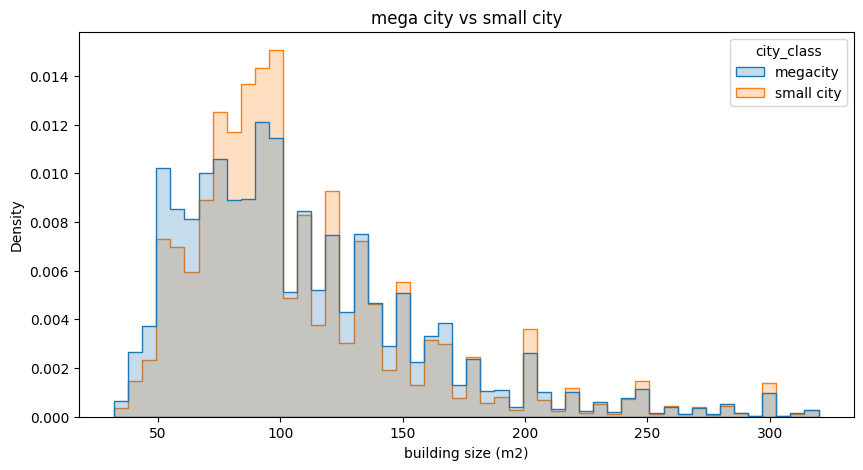

In [10]:
#groupby
print(result.groupby('city_class')['building_size'].agg(['mean', 'median', 'std', 'count']))

#plt
plt.figure(figsize=(10, 5))
sns.histplot(data=result, x='building_size', hue='city_class',bins=50, stat='density', common_norm=False, element='step')
plt.xlabel('building size (m2)')
plt.title('mega city vs small city')
plt.show()

In [11]:
result['city_class'].value_counts()

city_class
megacity      347389
small city    313656
Name: count, dtype: int64